In [95]:
from neural_priors.utils.data import Subject, get_all_subject_ids

from tqdm.contrib.itertools import product
import os.path as op
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

bids_folder = '/data/ds-neuralpriors'
roi = 'NPCr'

In [96]:
natural_pars_smoothed = pd.read_csv(op.join(bids_folder, 'derivatives', 'summary_encoding_models.natural_space.smoothed', f'group_roi-{roi}_parameters.tsv'), sep='\t', header=[0, 1], index_col=[0,1,2])
logspace_pars_smoothed = pd.read_csv(op.join(bids_folder, 'derivatives', 'summary_encoding_models.logspace.smoothed', f'group_roi-{roi}_parameters.tsv'), sep='\t', header=[0, 1], index_col=[0,1,2])
alpha_pars_smoothed = pd.read_csv(op.join(bids_folder, 'derivatives', 'summary_encoding_models.alpha.smoothed', f'group_roi-{roi}_parameters.tsv'), sep='\t', header=[0, 1], index_col=[0,1,2])


logspace_pars_smoothed['mu'] = np.exp(logspace_pars_smoothed['mu'])

pars = pd.concat([natural_pars_smoothed, logspace_pars_smoothed, alpha_pars_smoothed],
                 keys=[('natural', 'smoothed'), ('logspace', 'smoothed'), ('alpha', 'smoothed')],
                    names=['space', 'smoothing'], axis=0)

pars.rename_axis(index={'level_3':'voxel', None:'voxel', 'subject_id':'subject'}, inplace=True)

In [97]:
pars.groupby(['model_label', 'space', 'subject']).size().groupby(['model_label', 'space']).size()

model_label  space   
1            alpha       39
             logspace    39
             natural     39
2            alpha       39
             logspace    39
             natural     39
3            alpha       39
             logspace    39
             natural     39
4            logspace    39
             natural     39
5            logspace    39
             natural     39
6            alpha       39
             logspace    39
             natural     39
7            logspace    39
             natural     39
8            logspace    39
             natural     39
9            logspace    39
             natural     39
10           logspace    39
             natural     39
11           logspace    39
             natural     39
12           alpha       39
13           alpha       39
14           alpha       35
15           alpha       39
16           alpha       39
17           alpha       39
dtype: int64

In [98]:
pars

parameter                                           mu                   sd  \
range                                           narrow       wide    narrow   
space   smoothing subject model_label voxel                                   
natural smoothed  1       1           0      10.943486  10.943486  1.389957   
                                      1      45.297676  45.297676  1.098172   
                                      2      45.338240  45.338240  1.067531   
                                      3      45.309338  45.309338  1.089480   
                                      4      11.575078  11.575078  1.056056   
...                                                ...        ...       ...   
alpha   smoothed  41      17          689     8.635925  12.666874  1.414640   
                                      690     7.746444  11.336838  0.030481   
                                      691     9.362240  13.752928  1.384482   
                                      692     9.078219  13.328234  0.461835   
                                      693     9.880164  14.527376  1.378823   

parameter                                             amplitude            \
range                                            wide    narrow      wide   
space   smoothing subject model_label voxel                                 
natural smoothed  1       1           0      1.389957  0.293845  0.293845   
                                      1      1.098172  0.034831  0.034831   
                                      2      1.067531  0.028312  0.028312   
                                      3      1.089480  0.035011  0.035011   
                                      4      1.056056  0.374618  0.374618   
...                                               ...       ...       ...   
alpha   smoothed  41      17          689    1.414640  0.837071  0.837071   
                                      690    0.030481  0.495501  0.495501   
                                      691    1.384482  0.951490  0.951490   
                                      692    0.461835  0.204397  0.204397   
                                      693    1.378823  0.852206  0.852206   

parameter                                    baseline                      r2  \
range                                          narrow      wide           nan   
space   smoothing subject model_label voxel                                     
natural smoothed  1       1           0     -0.118108 -0.118108  8.020937e-03   
                                      1     -0.487767 -0.487767 -1.192093e-07   
                                      2     -0.477014 -0.477014  0.000000e+00   
                                      3     -0.271681 -0.271681 -1.192093e-07   
                                      4     -0.110368 -0.110368  8.203387e-03   
...                                               ...       ...           ...   
alpha   smoothed  41      17          689   -0.406943 -0.406943  2.450311e-02   
                                      690    0.282765  0.282765  9.237349e-03   
                                      691   -0.624313 -0.624313  2.559143e-02   
                                      692   -0.136444 -0.136444  1.307845e-02   
                                      693   -0.702486 -0.702486  1.279855e-02   

parameter                                        cvr2   alpha          \
range                                             nan  narrow    wide   
space   smoothing subject model_label voxel                             
natural smoothed  1       1           0     -0.019104     NaN     NaN   
                                      1     -0.016332     NaN     NaN   
                                      2     -0.009276     NaN     NaN   
                                      3     -0.011063     NaN     NaN   
                                      4     -0.013769     NaN     NaN   
...                                               ...     ...     ...   
alpha   smoothed  41  

In [99]:
cvr2 = pars[(pars['mu'] > 10.0).all(axis=1)]['cvr2']
cvr2.columns = ['cvr2']
cvr2 = cvr2.unstack(['space', 'model_label'])#['cvr2'].drop([ 5, 6, 7, 8], axis=1)
mask = cvr2.gt(0).any(axis=1) & cvr2.notna().all(axis=1)
masked_cvr2 = cvr2[mask]

/var/folders/d4/cpqhwlbn301clph1qk64k01nmjkty3/T/ipykernel_11544/1899673466.py:1: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  tmp = cvr2.stack(['space', 'model_label'])['cvr2']


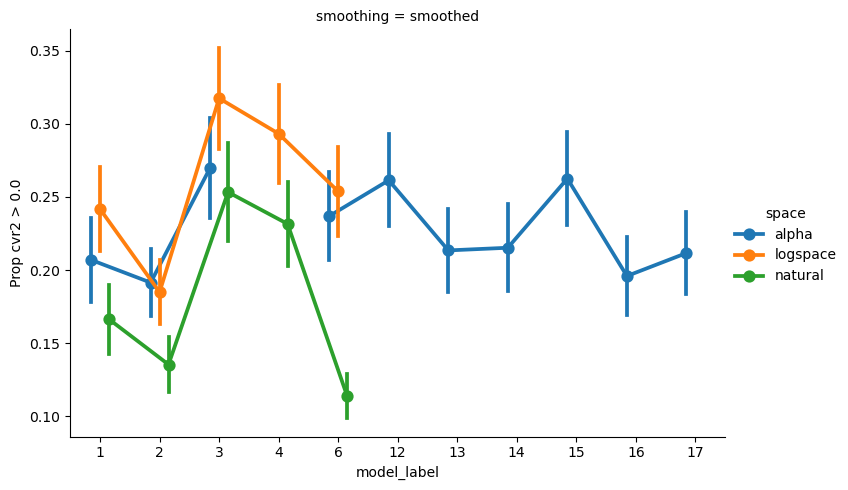

In [100]:
tmp = cvr2.stack(['space', 'model_label'])['cvr2']
tmp = tmp[tmp.notna()]


# Only selct model 1, 2, 3, 6, 12, 13
tmp = tmp[tmp.index.get_level_values('model_label').isin([1, 2, 3, 4, 6, 12, 13, 14, 15, 16, 17])]

tmp = (tmp > 0.0).groupby(['subject', 'smoothing', 'space', 'model_label']).mean().to_frame('Prop cvr2 > 0.0')

g = sns.catplot(data=tmp.reset_index(), x='model_label', y='Prop cvr2 > 0.0', hue='space', aspect=1.5, kind='point', col='smoothing', errorbar='se',
                dodge=.3)

# # g.set(xlabel=None)

# plt.title("Proportion of voxels with cvR2 > 0.0")

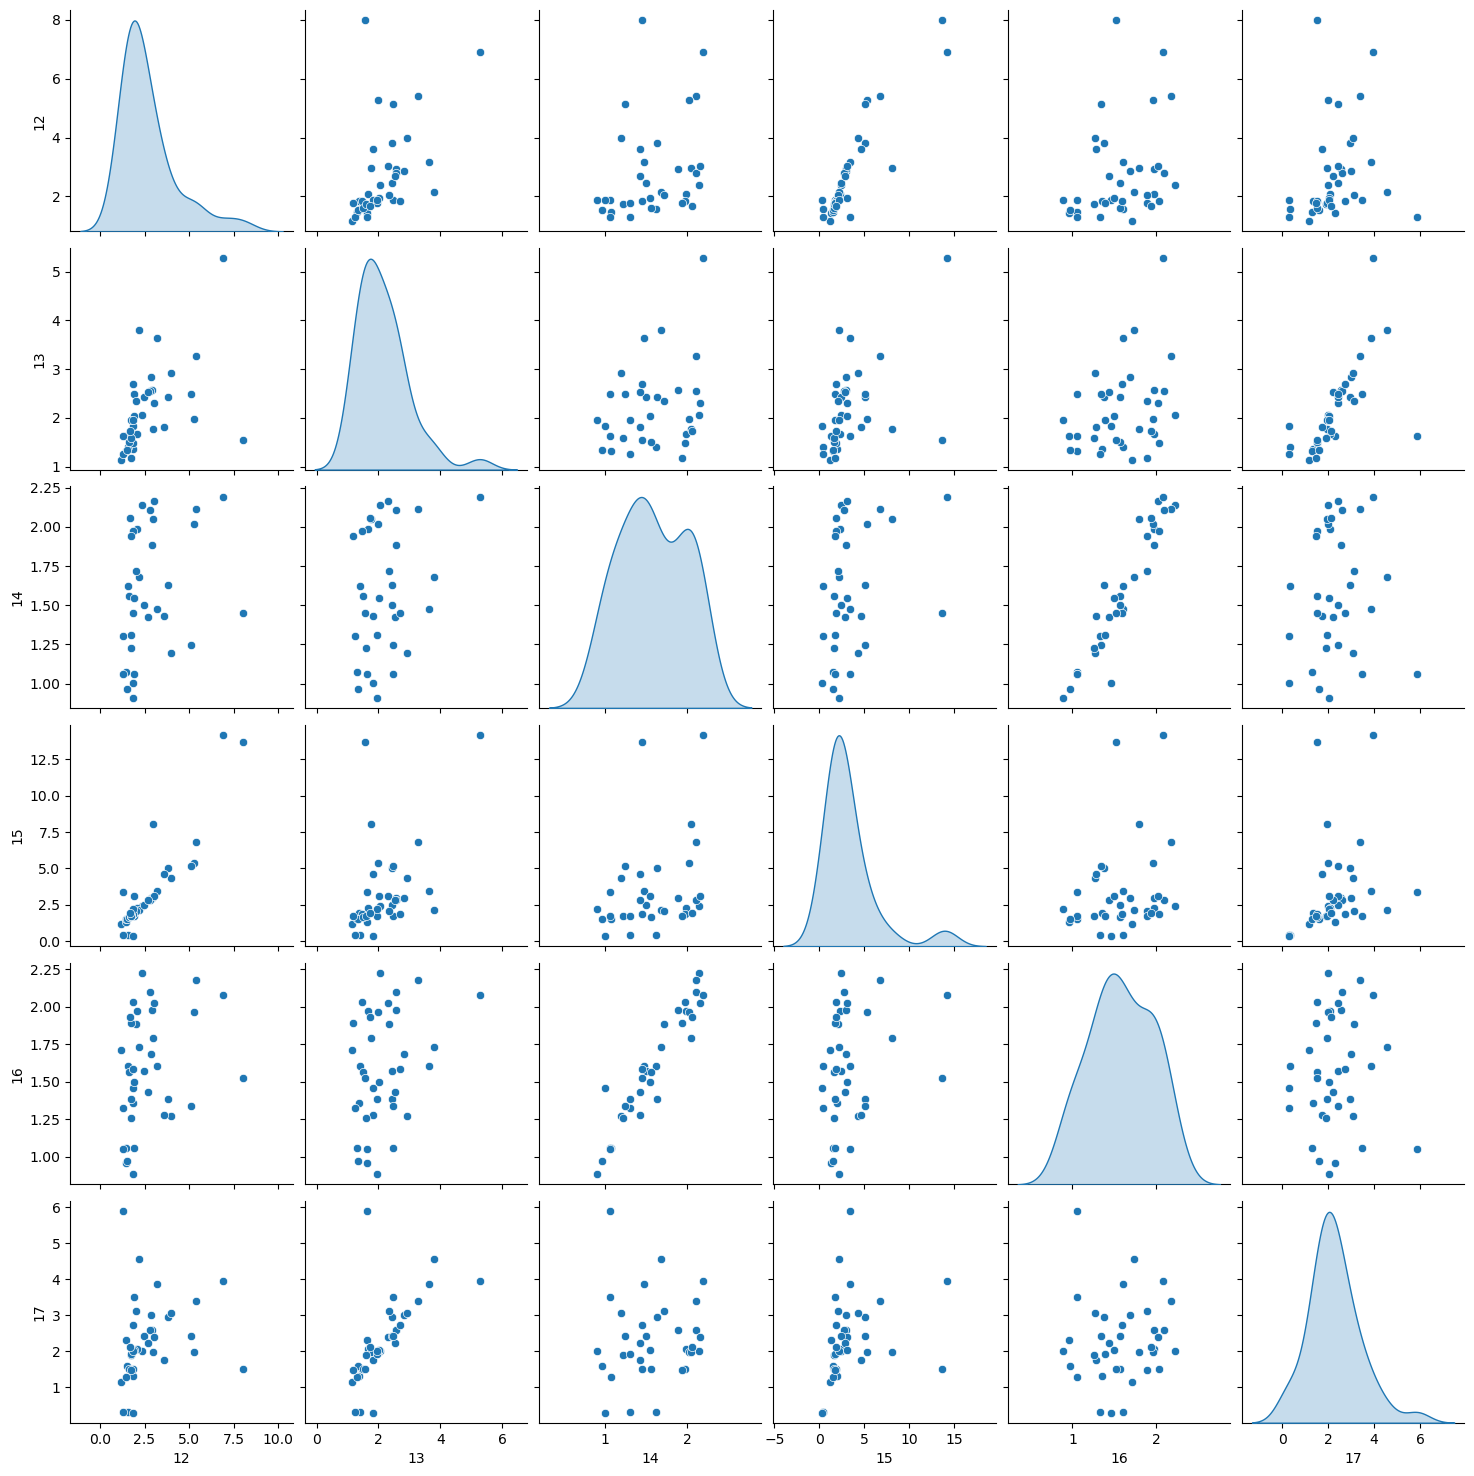

In [24]:
tmp = pars.loc['alpha'][('delta_wide', 'narrow')].groupby(['subject', 'model_label']).mean().unstack('model_label')

tmp = tmp.loc[:, ~tmp.isnull().all(axis=0)]
sns.pairplot(tmp, diag_kind='kde')

In [25]:
tmp.corr()

model_label,12,13,14,15,16,17
model_label,,,,,,
12,1.000000,0.510024,0.292466,0.904880,0.289018,0.216146
13,0.510024,1.000000,0.268333,0.478174,0.312335,0.659581
14,0.292466,0.268333,1.000000,0.306308,0.949644,0.075701
15,0.904880,0.478174,0.306308,1.000000,0.243280,0.287930
16,0.289018,0.312335,0.949644,0.243280,1.000000,0.050422
17,0.216146,0.659581,0.075701,0.287930,0.050422,1.000000


/var/folders/d4/cpqhwlbn301clph1qk64k01nmjkty3/T/ipykernel_11544/3821997561.py:1: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  tmp = cvr2.stack(['space', 'model_label'])['cvr2']
/Users/gdehol/mambaforge/envs/neural_priors/lib/python3.9/site-packages/seaborn/categorical.py:3399: UserWarning: 7.7% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


<Axes: xlabel='model_label', ylabel='Prop cvr2 > 0.0'>

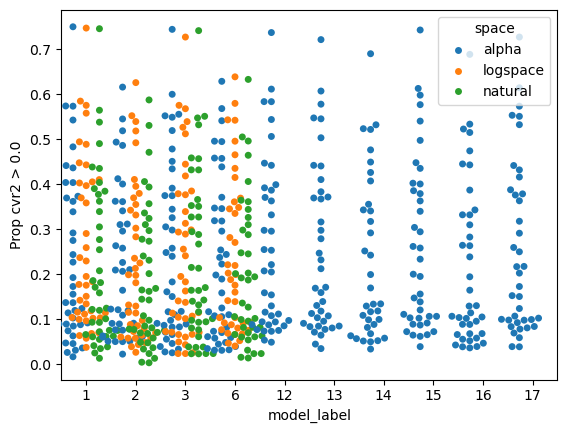

In [6]:
tmp = cvr2.stack(['space', 'model_label'])['cvr2']
tmp = tmp[tmp.notna()]
tmp = tmp[tmp.index.get_level_values('model_label').isin([1, 2, 3, 6, 12, 13, 14, 15, 16, 17])]

tmp = (tmp > 0.0).groupby(['subject', 'smoothing', 'space', 'model_label']).mean().to_frame('Prop cvr2 > 0.0')

sns.swarmplot(data=tmp.reset_index(), x='model_label', y='Prop cvr2 > 0.0', hue='space', dodge=True)


/var/folders/d4/cpqhwlbn301clph1qk64k01nmjkty3/T/ipykernel_11544/2654418905.py:1: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  tmp = cvr2[(cvr2 > 0.0).any(axis=1)].stack([1, 2]).groupby(['subject','model_label', 'space']).mean()


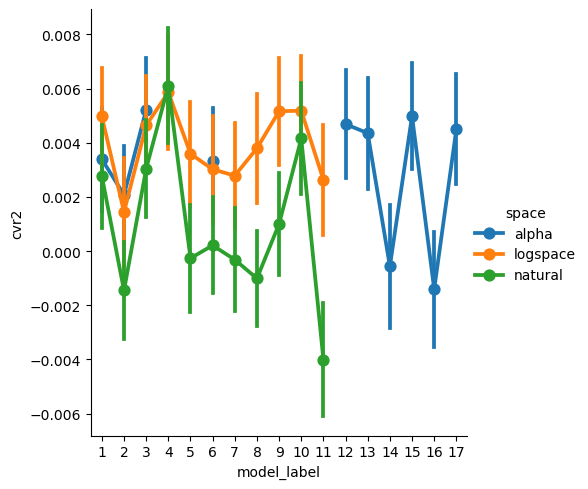

In [57]:
tmp = cvr2[(cvr2 > 0.0).any(axis=1)].stack([1, 2]).groupby(['subject','model_label', 'space']).mean()

sns.catplot(x='model_label', hue='space', y='cvr2', data=tmp.reset_index(), kind='point', errorbar='se')

# tmp.groupby(['subject','model_label', 'space']).mean()

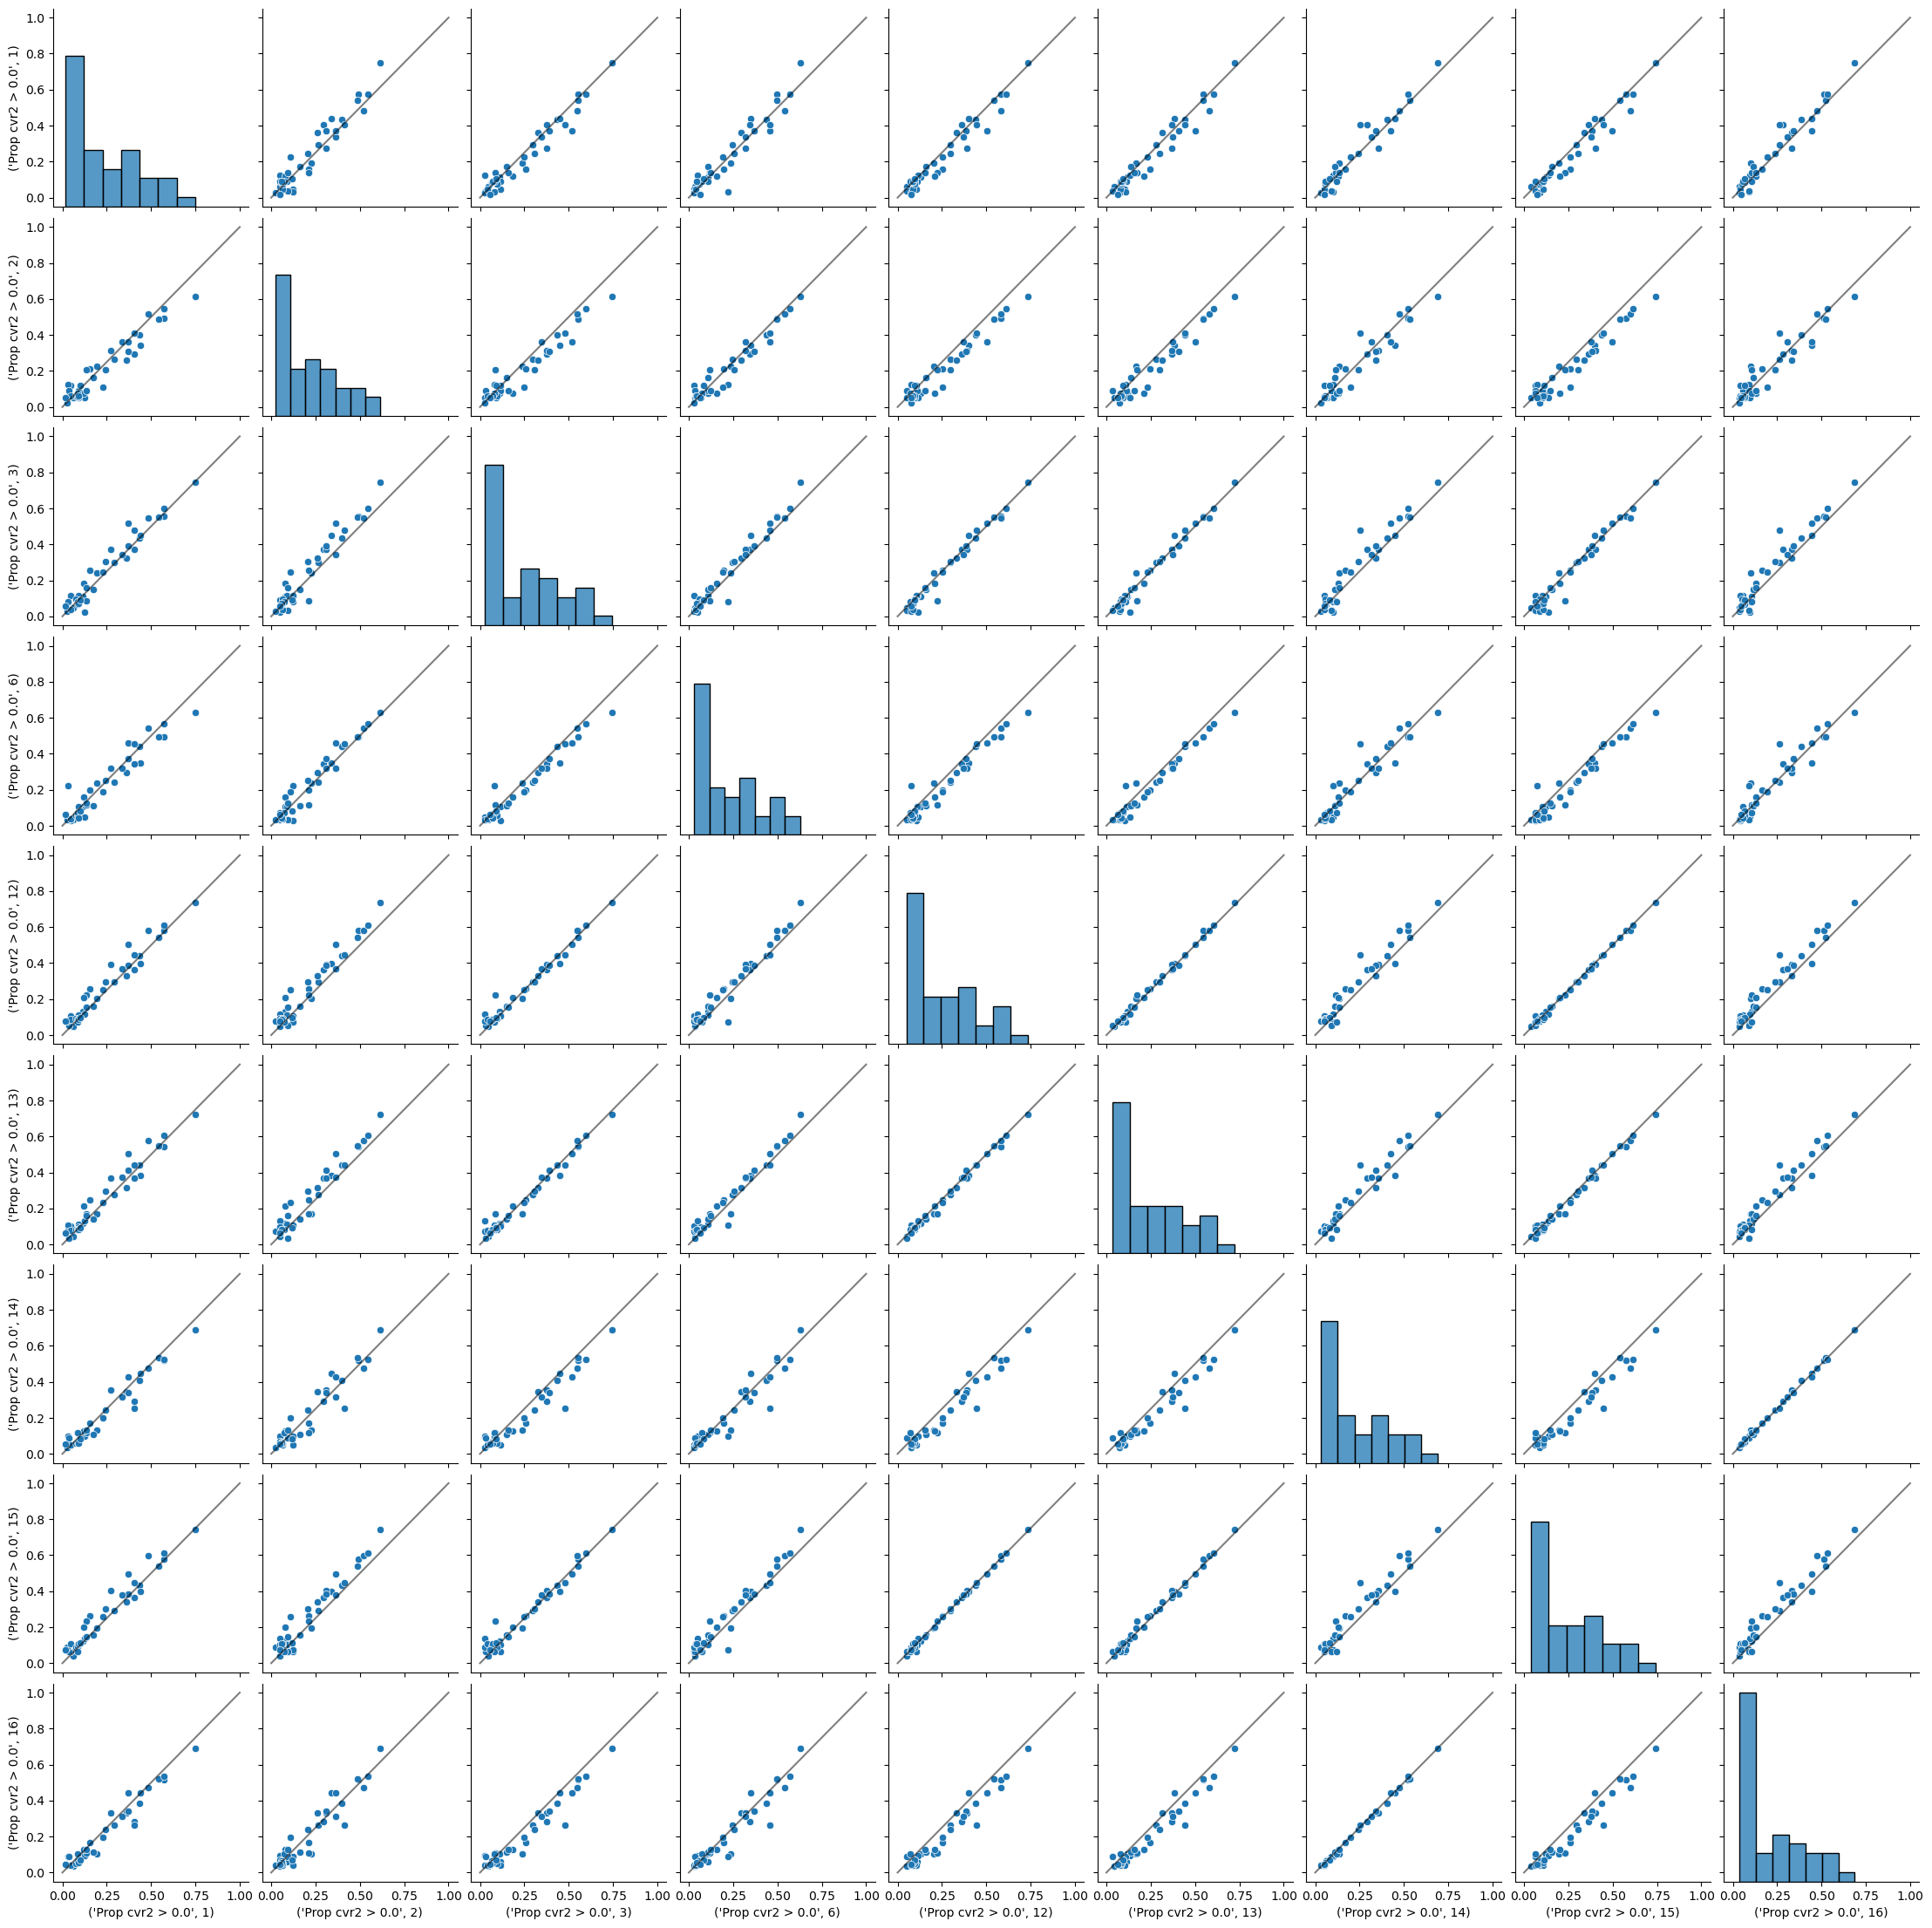

In [83]:
g = sns.pairplot(tmp.xs('alpha', 0, 'space').unstack('model_label'))

# plot identiy line
g.map_offdiag(lambda *args, **kwargs: plt.plot([0, 1], [0, 1], color='black', alpha=0.5))

In [65]:
import pingouin as pg
from IPython.display import display

# T-Test cvr2 pop > 0.0 between model 12 and 1 and 12 and 13 using paired t-test

tmp = (cvr2.xs('alpha', 1, level='space') > 0.0).groupby('subject').mean()['cvr2']

display(pg.ttest(tmp[12], tmp[1], paired=True))
display(pg.ttest(tmp[13], tmp[1], paired=True))
display(pg.ttest(tmp[12], tmp[6], paired=True))

# T-Test cvr2 pop > 0.0 between model 12 and 13 using paired t-test
display(pg.ttest(tmp[12], tmp[13], paired=True))
display(pg.ttest(tmp[12], tmp[14], paired=True))
print('Alpha versus lo')
display(pg.ttest(tmp[12], tmp[15], paired=True))
display(pg.ttest(tmp[12], tmp[13], paired=True))
display(pg.ttest(tmp[15], tmp[17], paired=True))
display(pg.ttest(tmp[15], tmp[1], paired=True))

tmp.mean()

,T,dof,alternative,p-val,CI95%,cohen-d,BF10,power
T-test,3.896107,38,two-sided,0.000384,"[0.01, 0.04]",0.13988,72.458,0.136323


,T,dof,alternative,p-val,CI95%,cohen-d,BF10,power
T-test,2.812381,38,two-sided,0.007739,"[0.01, 0.03]",0.104483,5.124,0.097496


,T,dof,alternative,p-val,CI95%,cohen-d,BF10,power
T-test,5.142507,38,two-sided,0.000008,"[0.02, 0.05]",0.187139,2345.996,0.206884


,T,dof,alternative,p-val,CI95%,cohen-d,BF10,power
T-test,2.729765,38,two-sided,0.009551,"[0.0, 0.01]",0.036009,4.279,0.055525


,T,dof,alternative,p-val,CI95%,cohen-d,BF10,power
T-test,5.36269,38,two-sided,0.000004,"[0.03, 0.07]",0.285222,4448.44,0.411574


...

,T,dof,alternative,p-val,CI95%,cohen-d,BF10,power
T-test,-0.603909,38,two-sided,0.549493,"[-0.01, 0.0]",0.006142,0.205,0.05016


,T,dof,alternative,p-val,CI95%,cohen-d,BF10,power
T-test,2.729765,38,two-sided,0.009551,"[0.0, 0.01]",0.036009,4.279,0.055525


,T,dof,alternative,p-val,CI95%,cohen-d,BF10,power
T-test,2.699838,38,two-sided,0.010299,"[0.0, 0.01]",0.036961,4.012,0.055822


,T,dof,alternative,p-val,CI95%,cohen-d,BF10,power
T-test,3.931267,38,two-sided,0.000346,"[0.01, 0.04]",0.145786,79.536,0.143976


model_label
1     0.233943
2     0.216158
3     0.250556
6     0.225900
12    0.260358
13    0.253582
15    0.261521
16    0.214499
17    0.254510
14    0.207097
dtype: float64

In [42]:
tmp[('logspace', 1)]

smoothing  subject  voxel
smoothed   1        7       -0.002410
                    10       0.006130
                    13       0.012361
                    14       0.009120
                    16       0.012371
                               ...   
           41       687      0.009689
                    688     -0.001575
                    689     -0.002034
                    691      0.000869
                    693     -0.000243
Name: (logspace, 1), Length: 14171, dtype: float64

In [52]:
pars.xs([('alpha', 'smoothed', 12), ('logspace', 'smoothed', 6)], level=[0, 1, 2])


TypeError: list keys are not supported in xs, pass a tuple instead

,T,dof,alternative,p-val,CI95%,cohen-d,BF10,power
T-test,0.855194,38,two-sided,0.397804,"[-0.0, 0.0]",0.051294,0.243,0.061247


,T,dof,alternative,p-val,CI95%,cohen-d,BF10,power
T-test,-0.021035,38,two-sided,0.983328,"[-0.0, 0.0]",0.001174,0.173,0.050006


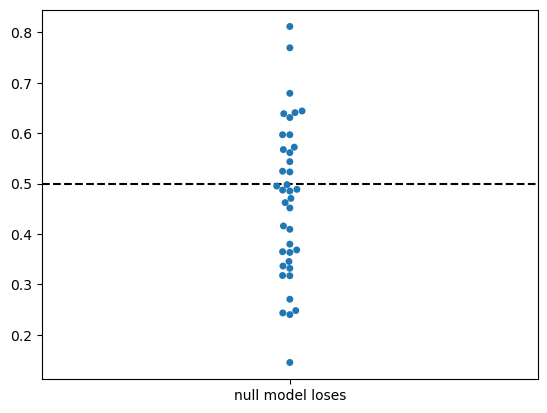

In [64]:
tmp = cvr2['cvr2']

tmp = tmp[(tmp > 0.0).any(axis=1)]

sns.swarmplot((tmp[('logspace', 1)] < tmp[('alpha', 13)]).groupby('subject').mean().to_frame('null model loses'))
plt.axhline(0.5, c='k', ls='--')

(tmp[('logspace', 1)] < tmp[('alpha', 15)]).groupby('subject').mean().to_frame('null model loses').describe()

display(pg.ttest(tmp[('logspace', 1)].groupby(['subject']).mean(), tmp[('alpha', 13)].groupby(['subject']).mean(), paired=True))
display(pg.ttest(tmp[('logspace', 1)].groupby(['subject']).mean(), tmp[('alpha', 15)].groupby(['subject']).mean(), paired=True))

In [ ]:
cvr2

cvr2                                          \
space                     natural                                           
model_label                    1         2         3         4         5    
smoothing subject voxel                                                     
smoothed  1       0     -0.019104 -0.034815 -0.007486 -0.024950 -0.037675   
                  1     -0.016332 -0.009900 -0.020954 -0.029854 -0.040936   
                  2     -0.009276 -0.034162 -0.019977 -0.022978 -0.030998   
                  3     -0.011063 -0.015421 -0.007268 -0.016718 -0.024584   
                  4     -0.013769 -0.019629 -0.006254 -0.021160 -0.029280   
...                           ...       ...       ...       ...       ...   
          41      689   -0.000658 -0.000415 -0.008232  0.014002 -0.021366   
                  690   -0.017327 -0.017358 -0.012527 -0.019461 -0.028966   
                  691    0.002585 -0.010697  0.000148  0.018301 -0.004865   
                  692   -0.018960 -0.028394 -0.012974 -0.008797 -0.040695   
                  693   -0.002419 -0.005437 -0.001703  0.005853 -0.012117   

                                                                           \
space                                                                       
model_label                    6         7         8         9         10   
smoothing subject voxel                                                     
smoothed  1       0     -0.033899 -0.032345 -0.036828 -0.026908 -0.028160   
                  1     -0.013093 -0.008714 -0.013965 -0.007868 -0.021304   
                  2     -0.025034 -0.014569 -0.032658 -0.009492 -0.013778   
                  3     -0.016449 -0.012560 -0.022744 -0.009871 -0.019083   
                  4     -0.023247 -0.024903 -0.033635 -0.024208 -0.020630   
...                           ...       ...       ...       ...       ...   
          41      689   -0.018236  0.009160 -0.010526  0.010655  0.013576   
                  690   -0.018106 -0.008383 -0.014687 -0.006112 -0.016174   
                  691    0.007148  0.009618 -0.013309  0.013007  0.016619   
                  692   -0.024679 -0.026522 -0.024659 -0.021579 -0.028893   
                  693    0.001169 -0.000834 -0.000806 -0.003132  0.004383   

                         ...                                          \
space                    ...     alpha                                 
model_label              ...        1         2         3         6    
smoothing subject voxel  ...                                           
smoothed  1       0      ... -0.013142 -0.037909 -0.020521 -0.028880   
                  1      ... -0.013027 -0.033067 -0.018421 -0.033416   
                  2      ... -0.012513 -0.011460 -0.014003 -0.015550   
                  3      ... -0.010402 -0.009471 -0.024986 -0.026097   
                  4      ... -0.017361 -0.027710 -0.007751 -0.018764   
...                      ...       ...       ...       ...       ...   
          41      689    ... -0.005503 -0.011799  0.001554  0.012569   
                  690    ... -0.016450 -0.010304 -0.011223 -0.013950   
                  691    ...  0.001587  0.003435  0.011472  0.014659   
                  692    ... -0.010290 -0.022472 -0.015353 -0.016648   
                  693    ... -0.001269  0.000081  0.003701  0.004668   

                                                                           \
space                                                                       
model_label                    12        13        15        16        17   
smoothing subject voxel                                                     
smoothed  1       0     -0.021276 -0.023236 -0.021487 -0.029429 -0.020723   
                  1     -0.018743 -0.023057 -0.022454 -0.026379 -0.018054   
                  2     -0.028038 -0.017652 -0.026277 -0.008995 -0.025593   
                  3     -0.010421 -0.008121 -0.008999 -0.005485 -0.008549   
                  4 

In [34]:
tmp[('alpha', 15)]

smoothing  subject  voxel
smoothed   1        7        0.003234
                    10      -0.006292
                    13       0.010863
                    14      -0.022508
                    16       0.014207
                               ...   
           41       687      0.003262
                    688      0.006570
                    689      0.009278
                    691      0.013472
                    693      0.004517
Name: (alpha, 15), Length: 14171, dtype: float64

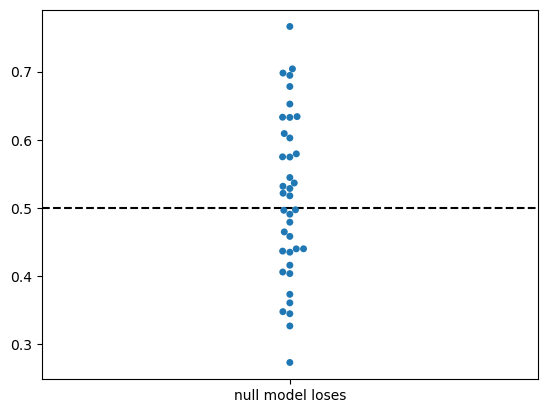

In [95]:
tmp = cvr2['cvr2']

tmp = tmp[(tmp > 0.0).any(axis=1)]

sns.swarmplot((tmp[('alpha', 12)] < tmp[('alpha', 15)]).groupby('subject').mean().to_frame('null model loses'))
plt.axhline(0.5, c='k', ls='--')

In [98]:
alpha_pars_smoothed

parameter                          mu                   sd              alpha  \
range                          narrow       wide    narrow      wide   narrow   
subject_id model_label                                                          
1          1           0     7.086685   7.086685  0.085504  0.085504 -0.51589   
                       1    37.338593  37.338593  2.165951  2.165951 -0.51589   
                       2    37.405792  37.405792  2.143753  2.143753 -0.51589   
                       3    15.066620  15.066620  0.017082  0.017082 -0.51589   
                       4    11.173774  11.173774  0.029218  0.029218 -0.51589   
...                               ...        ...       ...       ...      ...   
41         16          689  11.796010  14.089515  0.138690  0.138690  1.00000   
                       690  23.784609  32.335007  1.960861  1.960861  1.00000   
                       691  12.085897  14.530695  5.294994  5.294994  1.00000   
                       692  10.490897  12.103258  5.439610  5.439610  1.00000   
                       693  12.351892  14.935513  6.899196  6.899196  1.00000   

parameter                           amplitude            baseline            \
range                          wide    narrow      wide    narrow      wide   
subject_id model_label                                                        
1          1           0   -0.51589  0.790241  0.790241 -0.115916 -0.115916   
                       1   -0.51589  0.126115  0.126115 -0.613481 -0.613481   
                       2   -0.51589  0.161097  0.161097 -0.637712 -0.637712   
                       3   -0.51589  0.299644  0.299644 -0.308781 -0.308781   
                       4   -0.51589  0.323873  0.323873 -0.108512 -0.108512   
...                             ...       ...       ...       ...       ...   
41         16          689  1.00000  0.672381  0.672381  0.319182  0.319182   
                       690  1.00000  0.094948  0.094948  0.269905  0.269905   
                       691  1.00000  0.172444  0.172444  0.151380  0.151380   
                       692  1.00000  0.177878  0.177878 -0.113204 -0.113204   
                       693  1.00000  0.143963  0.143963 -0.006387 -0.006387   

parameter                         r2      cvr2 delta_wide       \
range                            nan       nan     narrow wide   
subject_id model_label                                           
1          1           0    0.006909 -0.013142        NaN  NaN   
                       1   -0.000035 -0.013027        NaN  NaN   
                       2   -0.000049 -0.012513        NaN  NaN   
                       3    0.014905 -0.010402        NaN  NaN   
                       4    0.007363 -0.017361        NaN  NaN   
...                              ...       ...        ...  ...   
41         16          689  0.024924 -0.003172        NaN  NaN   
                       690  0.007956 -0.026276        NaN  NaN   
                       691  0.020624 -0.000039        NaN  NaN   
                       692  0.014869 -0.029394        NaN  NaN   
                       693  0.009606 -0.014930        NaN  NaN   

parameter                  lower_bound_range       
range                                 narrow wide  
subject_id model_label                             
1          1           0                 NaN  NaN  
                       1                 NaN  NaN  
                       2                 NaN  NaN  
                       3                 NaN  NaN  
                       4                 NaN  NaN  
...                                      ...  ...  
41         16          689               NaN  NaN  
                       690               NaN  NaN  
                       691               NaN  NaN  
                       692               NaN  NaN  
                       693               NaN  NaN  

[277903 rows x 16 columns]

/Users/gdehol/mambaforge/envs/neural_priors/lib/python3.9/site-packages/seaborn/categorical.py:3399: UserWarning: 5.1% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


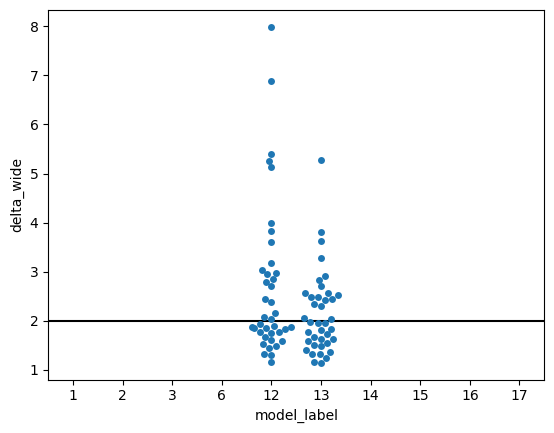

In [97]:
sns.swarmplot(data=alpha_pars_smoothed[('delta_wide', 'wide')].groupby(['subject_id', 'model_label']).mean().to_frame('delta_wide'), x='model_label', y='delta_wide')

plt.axhline(2.0, c='k')

/Users/gdehol/mambaforge/envs/neural_priors/lib/python3.9/site-packages/seaborn/categorical.py:3399: UserWarning: 76.9% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/Users/gdehol/mambaforge/envs/neural_priors/lib/python3.9/site-packages/seaborn/categorical.py:3399: UserWarning: 74.3% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


/Users/gdehol/mambaforge/envs/neural_priors/lib/python3.9/site-packages/seaborn/categorical.py:3399: UserWarning: 87.2% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/Users/gdehol/mambaforge/envs/neural_priors/lib/python3.9/site-packages/seaborn/categorical.py:3399: UserWarning: 85.7% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


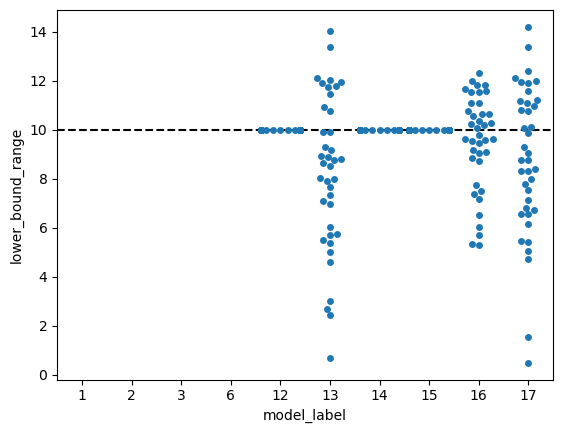

In [85]:
sns.swarmplot(data=alpha_pars_smoothed[('lower_bound_range', 'wide')].groupby(['subject_id', 'model_label']).mean().to_frame('lower_bound_range'), x='model_label', y='lower_bound_range')
plt.axhline(10.0, c='k', ls='--')

/Users/gdehol/mambaforge/envs/neural_priors/lib/python3.9/site-packages/seaborn/categorical.py:3399: UserWarning: 10.3% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/Users/gdehol/mambaforge/envs/neural_priors/lib/python3.9/site-packages/seaborn/categorical.py:3399: UserWarning: 7.7% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/Users/gdehol/mambaforge/envs/neural_priors/lib/python3.9/site-packages/seaborn/categorical.py:3399: UserWarning: 85.7% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/Users/gdehol/mambaforge/envs/neural_priors/lib/python3.9/site-packages/seaborn/categorical.py:3399: UserWarning: 87.2% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, Us

Text(0.5, 0.0, 'log')

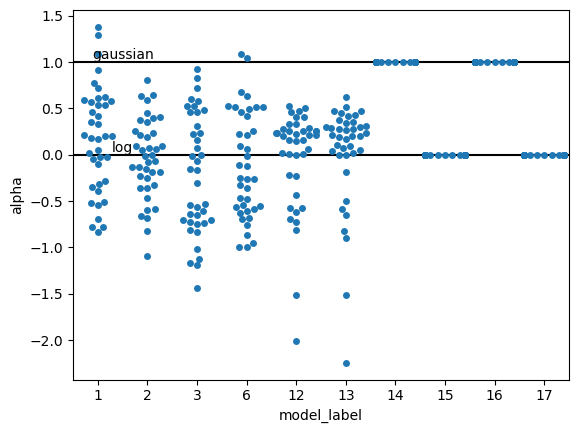

In [86]:
sns.swarmplot(data=alpha_pars_smoothed[('alpha', 'wide')].groupby(['subject_id', 'model_label']).mean().to_frame('alpha'), x='model_label', y='alpha')

plt.axhline(1.0, label='gaussian', c='k')
plt.axhline(0.0, label='log', c='k')

ax = plt.gca()
ax.text(0.5, 1.0, 'gaussian', verticalalignment='bottom', horizontalalignment='center')
ax.text(0.5, 0.0, 'log', verticalalignment='bottom', horizontalalignment='center')

# plt.legend()

/Users/gdehol/mambaforge/envs/neural_priors/lib/python3.9/site-packages/seaborn/categorical.py:3399: UserWarning: 5.1% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


/Users/gdehol/mambaforge/envs/neural_priors/lib/python3.9/site-packages/seaborn/categorical.py:3399: UserWarning: 5.7% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/Users/gdehol/mambaforge/envs/neural_priors/lib/python3.9/site-packages/seaborn/categorical.py:3399: UserWarning: 10.3% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


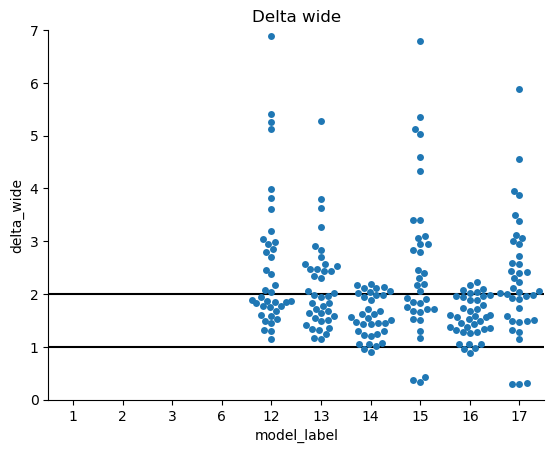

In [87]:
sns.swarmplot(data=alpha_pars_smoothed[('delta_wide', 'wide')].groupby(['subject_id', 'model_label']).mean().to_frame('delta_wide'), x='model_label', y='delta_wide')

ax = plt.gca()

# plt.legend()

plt.title('Delta wide')

sns.despine()

plt.ylim(0, 7)

plt.axhline(1.0, c='k', )
plt.axhline(2.0, c='k', )

/Users/gdehol/mambaforge/envs/neural_priors/lib/python3.9/site-packages/seaborn/categorical.py:3399: UserWarning: 76.9% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/Users/gdehol/mambaforge/envs/neural_priors/lib/python3.9/site-packages/seaborn/categorical.py:3399: UserWarning: 74.3% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


/Users/gdehol/mambaforge/envs/neural_priors/lib/python3.9/site-packages/seaborn/categorical.py:3399: UserWarning: 87.2% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/Users/gdehol/mambaforge/envs/neural_priors/lib/python3.9/site-packages/seaborn/categorical.py:3399: UserWarning: 85.7% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


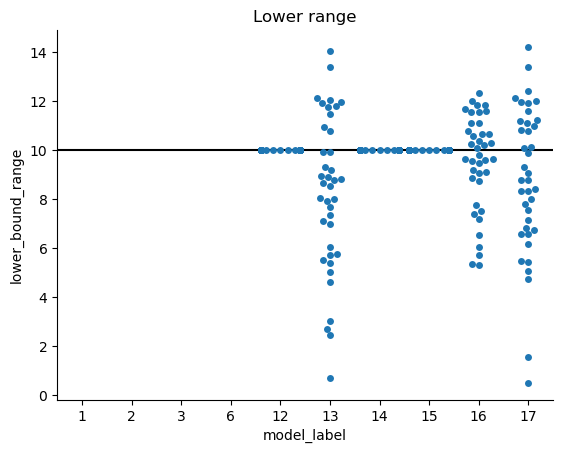

In [75]:
sns.swarmplot(data=alpha_pars_smoothed[('lower_bound_range', 'wide')].groupby(['subject_id', 'model_label']).mean().to_frame('lower_bound_range'), x='model_label', y='lower_bound_range')

ax = plt.gca()

# plt.legend()

plt.title('Lower range')

sns.despine()

# plt.ylim(0, 7)

plt.axhline(10.0, c='k', )

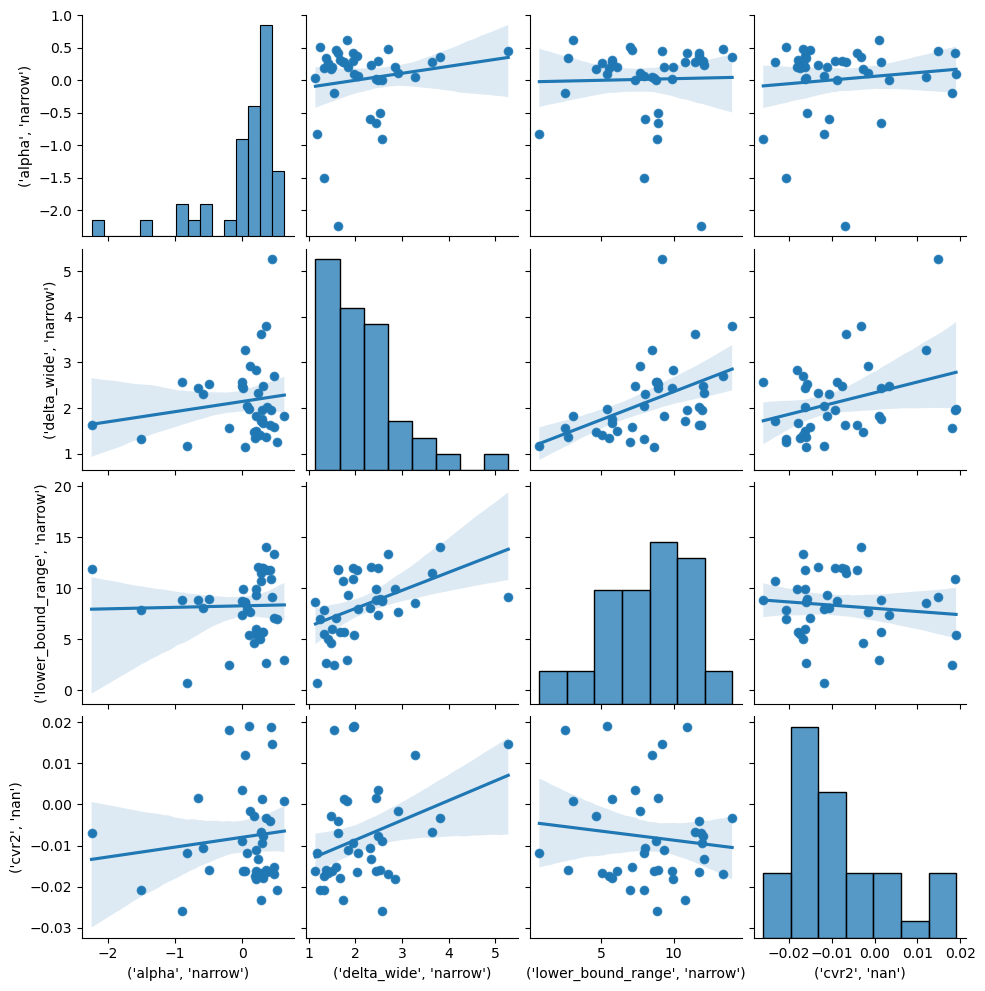

In [258]:
tmp = pars.xs(13, level='model_label')[[('alpha', 'narrow'), ('delta_wide', 'narrow'), ('lower_bound_range', 'narrow'), ('cvr2', 'nan')]].groupby('subject').mean()

g = sns.pairplot(tmp)


g.map_offdiag(sns.regplot)

,n,r,CI95%,p-val,BF10,power
pearson,34,0.231756,"[-0.12, 0.53]",0.187219,0.492,0.264806


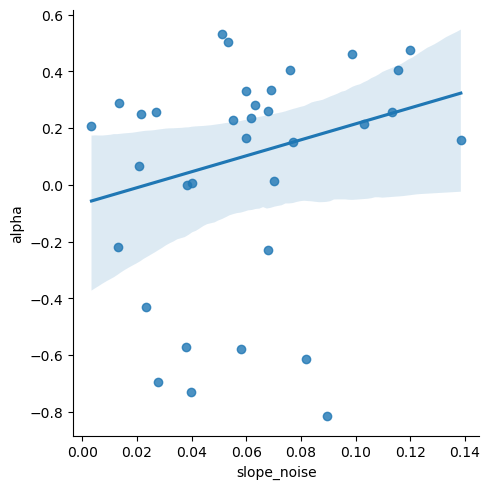

In [33]:
slope_noise= pd.read_csv('/Users/gdehol/Downloads/slope_noise.tsv', index_col=0, sep='\t')
slope_noise.columns = ['slope_noise']

slope_noise = slope_noise[slope_noise > 0]

alpha = alpha_pars_smoothed.xs(12, level='model_label')[('alpha', 'wide')].groupby(['subject_id']).mean().to_frame('alpha')

alpha = alpha[(alpha < 1.0) & (alpha > -1.0)]

# Rename index to subject
alpha.index = alpha.index.rename('subject')

# Merge with slope_noise
# slope_noise.join(alpha)

df = slope_noise.join(alpha)

sns.lmplot(data=df, x='slope_noise', y='alpha', robust=True)

pg.corr(df['alpha'], df['slope_noise'])

In [16]:
alpha_pars_smoothed

parameter                          mu                   sd              alpha  \
range                          narrow       wide    narrow      wide   narrow   
subject_id model_label                                                          
1          1           0     7.086685   7.086685  0.085504  0.085504 -0.51589   
                       1    37.338593  37.338593  2.165951  2.165951 -0.51589   
                       2    37.405792  37.405792  2.143753  2.143753 -0.51589   
                       3    15.066620  15.066620  0.017082  0.017082 -0.51589   
                       4    11.173774  11.173774  0.029218  0.029218 -0.51589   
...                               ...        ...       ...       ...      ...   
41         13          689   9.402958  13.231614  0.660519  0.660519 -0.19117   
                       690   8.152626  11.293134  0.020645  0.020645 -0.19117   
                       691   9.949208  14.078506  0.659546  0.659546 -0.19117   
                       692   6.866235   9.298749  0.563544  0.563544 -0.19117   
                       693  10.251571  14.547280  0.663104  0.663104 -0.19117   

parameter                           amplitude            baseline            \
range                          wide    narrow      wide    narrow      wide   
subject_id model_label                                                        
1          1           0   -0.51589  0.790241  0.790241 -0.115916 -0.115916   
                       1   -0.51589  0.126115  0.126115 -0.613481 -0.613481   
                       2   -0.51589  0.161097  0.161097 -0.637712 -0.637712   
                       3   -0.51589  0.299644  0.299644 -0.308781 -0.308781   
                       4   -0.51589  0.323873  0.323873 -0.108512 -0.108512   
...                             ...       ...       ...       ...       ...   
41         13          689 -0.19117  0.657411  0.657411 -0.229220 -0.229220   
                       690 -0.19117  0.429625  0.429625  0.282831  0.282831   
                       691 -0.19117  0.762275  0.762275 -0.435980 -0.435980   
                       692 -0.19117  0.343494  0.343494 -0.255899 -0.255899   
                       693 -0.19117  0.668474  0.668474 -0.517971 -0.517971   

parameter                         r2      cvr2 delta_wide            \
range                            nan       nan     narrow      wide   
subject_id model_label                                                
1          1           0    0.006909 -0.013142        NaN       NaN   
                       1   -0.000035 -0.013027        NaN       NaN   
                       2   -0.000049 -0.012513        NaN       NaN   
                       3    0.014905 -0.010402        NaN       NaN   
                       4    0.007363 -0.017361        NaN       NaN   
...                              ...       ...        ...       ...   
41         13          689  0.024294  0.002676   1.550372  1.550372   
                       690  0.009222 -0.023151   1.550372  1.550372   
                       691  0.025615  0.015569   1.550372  1.550372   
                       692  0.013155 -0.018057   1.550372  1.550372   
                       693  0.012694  0.005992   1.550372  1.550372   

parameter                  lower_bound_range            
range                                 narrow      wide  
subject_id model_label                                  
1          1           0                 NaN       NaN  
                       1                 NaN       NaN  
                       2                 NaN       NaN  
                       3                 NaN       NaN  
                       4                 NaN       NaN  
...                                      ...       ...  
41         13          689          2.446476  2.446476  
                       690          2.446476  2.446476  
                       691          2.446476  2.446476  
                       692          2.446476  2.446476  
                      

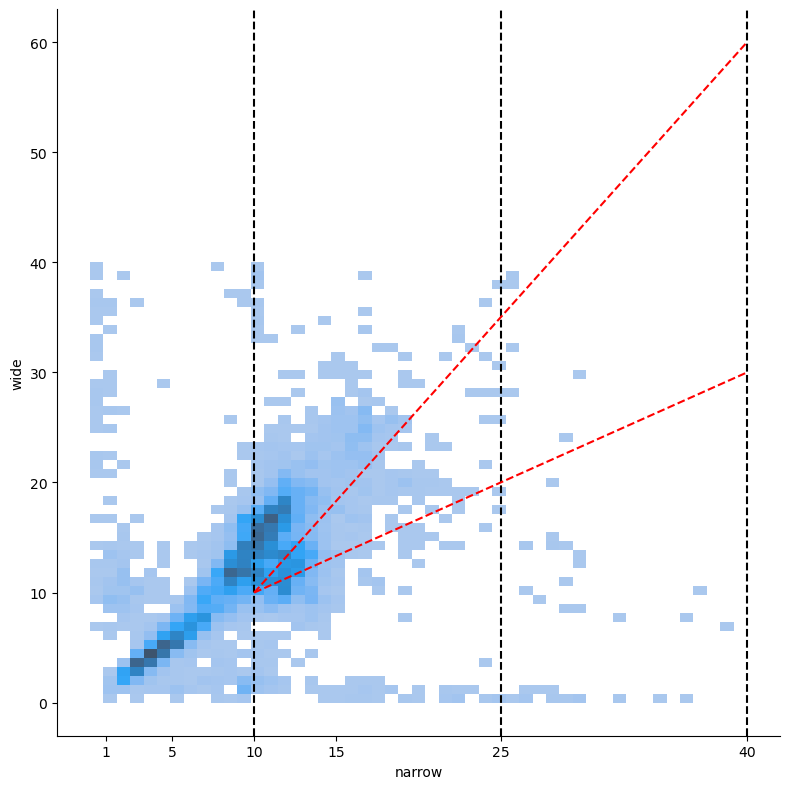

In [78]:
pars3 = pars.loc['logspace'].xs(6, 0, 'model_label')
pars3 = pars3[pars3[('cvr2', 'nan')].gt(0.0)]

mu = np.exp(pars3[['mu']].droplevel(0, 1))

mu
g = sns.FacetGrid(mu.reset_index(), height=8)

g.map_dataframe(sns.histplot, x='narrow', y='wide', bins=[np.linspace(0, 40, 50), np.linspace(0, 40, 50)])

g.map(plt.axvline, x=10, color='k', linestyle='--')
g.map(plt.axvline, x=25, color='k', linestyle='--')
g.map(plt.axvline, x=40, color='k', linestyle='--')

# # Put natural space xticks
g.axes[0, 0].set_xticks([1, 5, 10, 15, 25, 40])
g.axes[0, 0].set_xticklabels([1, 5, 10, 15, 25, 40])


# g.set(xlim=(1, 3.7), ylim=(1, 3.7))

# g.map(lambda *args, **kwargs: plt.plot([1, 3.7], [1, 3.7], 'k--'))

slope = 1.
g.map(lambda *args, **kwargs: plt.plot([10, 40], [10, slope*(40-10)], 'r--'))
slope = 2.
g.map(lambda *args, **kwargs: plt.plot([10, 40], [10, slope*(40-10)], 'r--'))

g.set_titles('Model {col_name} ({row_name})')


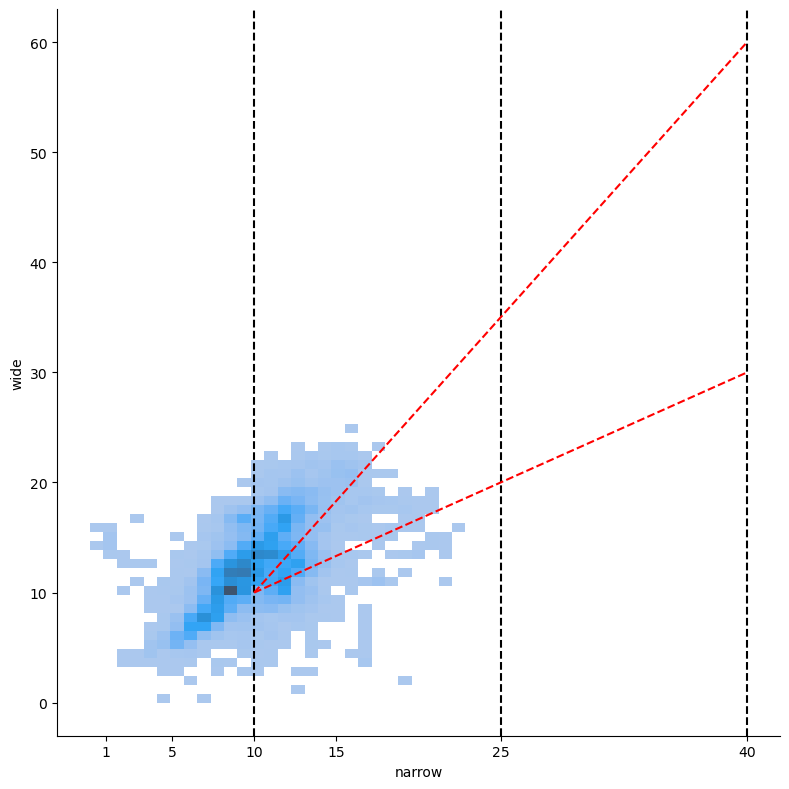

In [76]:
pars3 = pars.loc['alpha'].xs(6, 0, 'model_label')
pars3 = pars3[pars3[('cvr2', 'nan')].gt(0.0)]

mu = pars3[['mu']].droplevel(0, 1)

mu
g = sns.FacetGrid(mu.reset_index(), height=8)

g.map_dataframe(sns.histplot, x='narrow', y='wide', bins=[np.linspace(0, 40, 50), np.linspace(0, 40, 50)])

g.map(plt.axvline, x=10, color='k', linestyle='--')
g.map(plt.axvline, x=25, color='k', linestyle='--')
g.map(plt.axvline, x=40, color='k', linestyle='--')

# # Put natural space xticks
g.axes[0, 0].set_xticks([1, 5, 10, 15, 25, 40])
g.axes[0, 0].set_xticklabels([1, 5, 10, 15, 25, 40])


# g.set(xlim=(1, 3.7), ylim=(1, 3.7))

# g.map(lambda *args, **kwargs: plt.plot([1, 3.7], [1, 3.7], 'k--'))

slope = 1.
g.map(lambda *args, **kwargs: plt.plot([10, 40], [10, slope*(40-10)], 'r--'))
slope = 2.
g.map(lambda *args, **kwargs: plt.plot([10, 40], [10, slope*(40-10)], 'r--'))

g.set_titles('Model {col_name} ({row_name})')


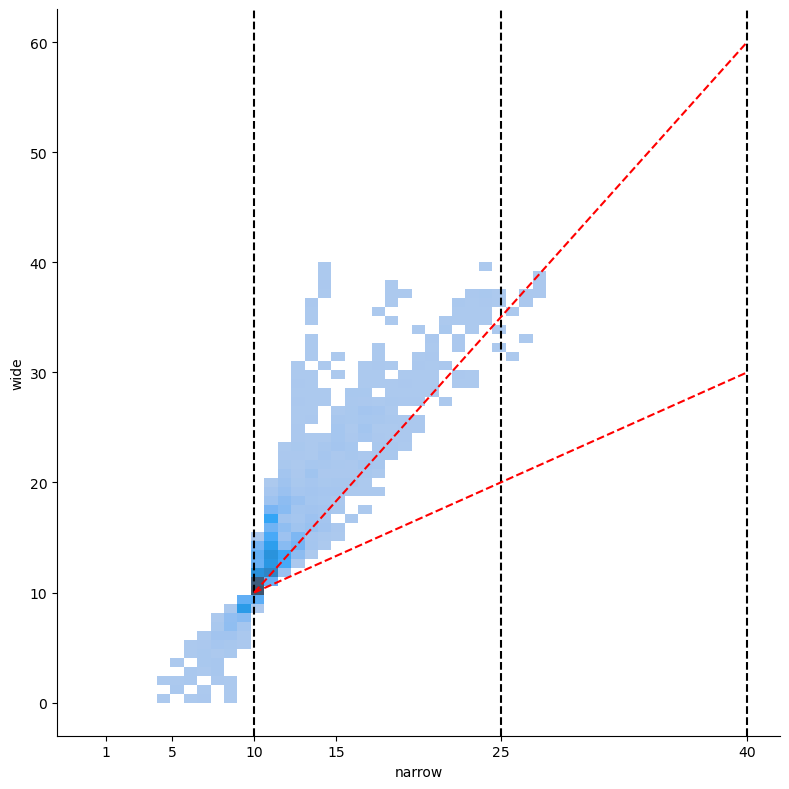

In [158]:
pars3 = pars.loc['alpha'].xs(12, 0, 'model_label')
pars3 = pars3[pars3[('cvr2', 'nan')].gt(0.0)]

mu = pars3[['mu']].droplevel(0, 1)

mu
g = sns.FacetGrid(mu.reset_index(), height=8)

g.map_dataframe(sns.histplot, x='narrow', y='wide', bins=[np.linspace(0, 40, 50), np.linspace(0, 40, 50)])

g.map(plt.axvline, x=10, color='k', linestyle='--')
g.map(plt.axvline, x=25, color='k', linestyle='--')
g.map(plt.axvline, x=40, color='k', linestyle='--')

# # Put natural space xticks
g.axes[0, 0].set_xticks([1, 5, 10, 15, 25, 40])
g.axes[0, 0].set_xticklabels([1, 5, 10, 15, 25, 40])


# g.set(xlim=(1, 3.7), ylim=(1, 3.7))

# g.map(lambda *args, **kwargs: plt.plot([1, 3.7], [1, 3.7], 'k--'))

slope = 1.
g.map(lambda *args, **kwargs: plt.plot([10, 40], [10, slope*(40-10)], 'r--'))
slope = 2.
g.map(lambda *args, **kwargs: plt.plot([10, 40], [10, slope*(40-10)], 'r--'))

g.set_titles('Model {col_name} ({row_name})')


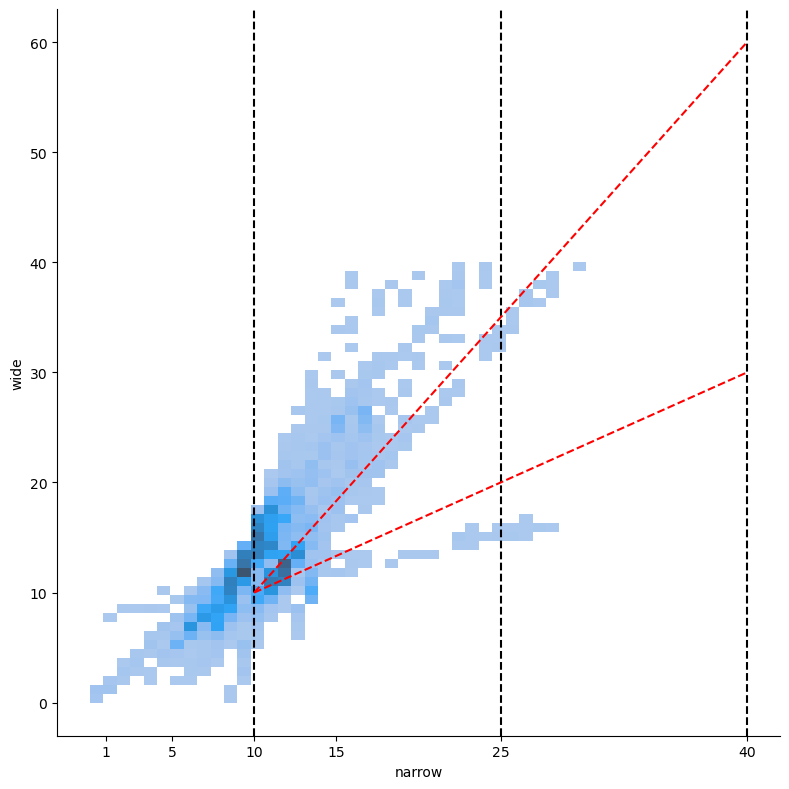

In [83]:
pars3 = pars.loc['alpha'].xs(17, 0, 'model_label')
pars3 = pars3[pars3[('cvr2', 'nan')].gt(0.0)]

mu = pars3[['mu']].droplevel(0, 1)

mu
g = sns.FacetGrid(mu.reset_index(), height=8)

g.map_dataframe(sns.histplot, x='narrow', y='wide', bins=[np.linspace(0, 40, 50), np.linspace(0, 40, 50)])

g.map(plt.axvline, x=10, color='k', linestyle='--')
g.map(plt.axvline, x=25, color='k', linestyle='--')
g.map(plt.axvline, x=40, color='k', linestyle='--')

# # Put natural space xticks
g.axes[0, 0].set_xticks([1, 5, 10, 15, 25, 40])
g.axes[0, 0].set_xticklabels([1, 5, 10, 15, 25, 40])


# g.set(xlim=(1, 3.7), ylim=(1, 3.7))

# g.map(lambda *args, **kwargs: plt.plot([1, 3.7], [1, 3.7], 'k--'))

slope = 1.
g.map(lambda *args, **kwargs: plt.plot([10, 40], [10, slope*(40-10)], 'r--'))
slope = 2.
g.map(lambda *args, **kwargs: plt.plot([10, 40], [10, slope*(40-10)], 'r--'))

g.set_titles('Model {col_name} ({row_name})')


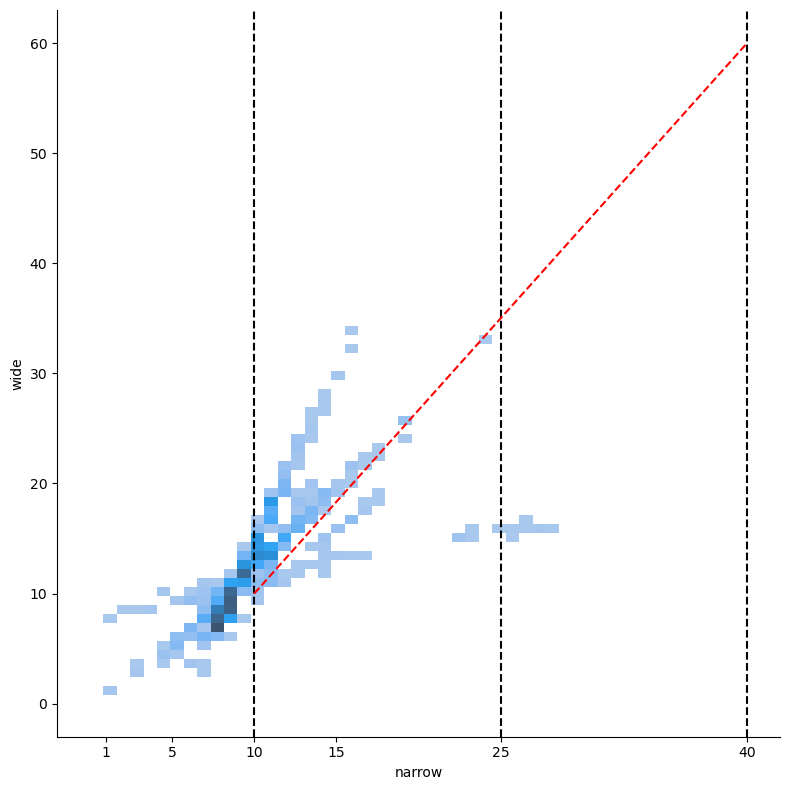

In [104]:
pars6 = pars.loc['alpha'].xs(17, 0, 'model_label')
pars6 = pars6[pars6[('cvr2', 'nan')].gt(0.0)]

mu = pars6[['mu']].droplevel(0, 1)

mu
g = sns.FacetGrid(mu.reset_index(), height=8)

g.map_dataframe(sns.histplot, x='narrow', y='wide', bins=[np.linspace(0, 40, 50), np.linspace(0, 40, 50)])

g.map(plt.axvline, x=10, color='k', linestyle='--')
g.map(plt.axvline, x=25, color='k', linestyle='--')
g.map(plt.axvline, x=40, color='k', linestyle='--')

# # Put natural space xticks
g.axes[0, 0].set_xticks([1, 5, 10, 15, 25, 40])
g.axes[0, 0].set_xticklabels([1, 5, 10, 15, 25, 40])


# g.set(xlim=(1, 3.7), ylim=(1, 3.7))

# g.map(lambda *args, **kwargs: plt.plot([1, 3.7], [1, 3.7], 'k--'))

slope = 2.
g.map(lambda *args, **kwargs: plt.plot([10, 40], [10, slope*(40-10)], 'r--'))

g.set_titles('Model {col_name} ({row_name})')


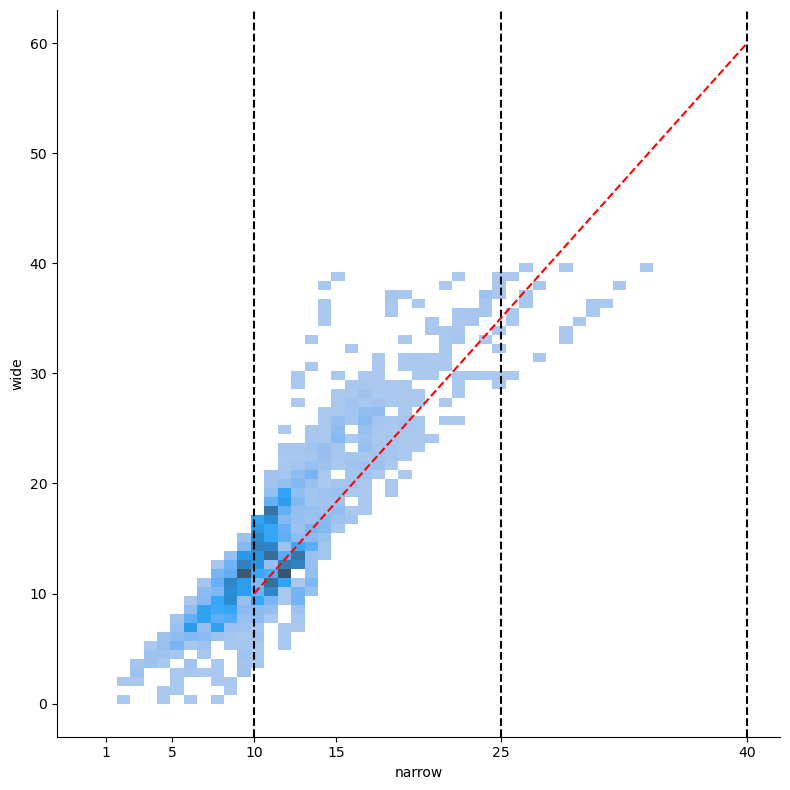

In [146]:
pars6 = pars.loc['alpha'].xs(13, 0, 'model_label')
pars6 = pars6[pars6[('cvr2', 'nan')].gt(0.0)]

mu = pars6[['mu']].droplevel(0, 1)

mu
g = sns.FacetGrid(mu.reset_index(), height=8)

g.map_dataframe(sns.histplot, x='narrow', y='wide', bins=[np.linspace(0, 40, 50), np.linspace(0, 40, 50)])

g.map(plt.axvline, x=10, color='k', linestyle='--')
g.map(plt.axvline, x=25, color='k', linestyle='--')
g.map(plt.axvline, x=40, color='k', linestyle='--')

# # Put natural space xticks
g.axes[0, 0].set_xticks([1, 5, 10, 15, 25, 40])
g.axes[0, 0].set_xticklabels([1, 5, 10, 15, 25, 40])


# g.set(xlim=(1, 3.7), ylim=(1, 3.7))

# g.map(lambda *args, **kwargs: plt.plot([1, 3.7], [1, 3.7], 'k--'))

slope = 2.
g.map(lambda *args, **kwargs: plt.plot([10, 40], [10, slope*(40-10)], 'r--'))

g.set_titles('Model {col_name} ({row_name})')


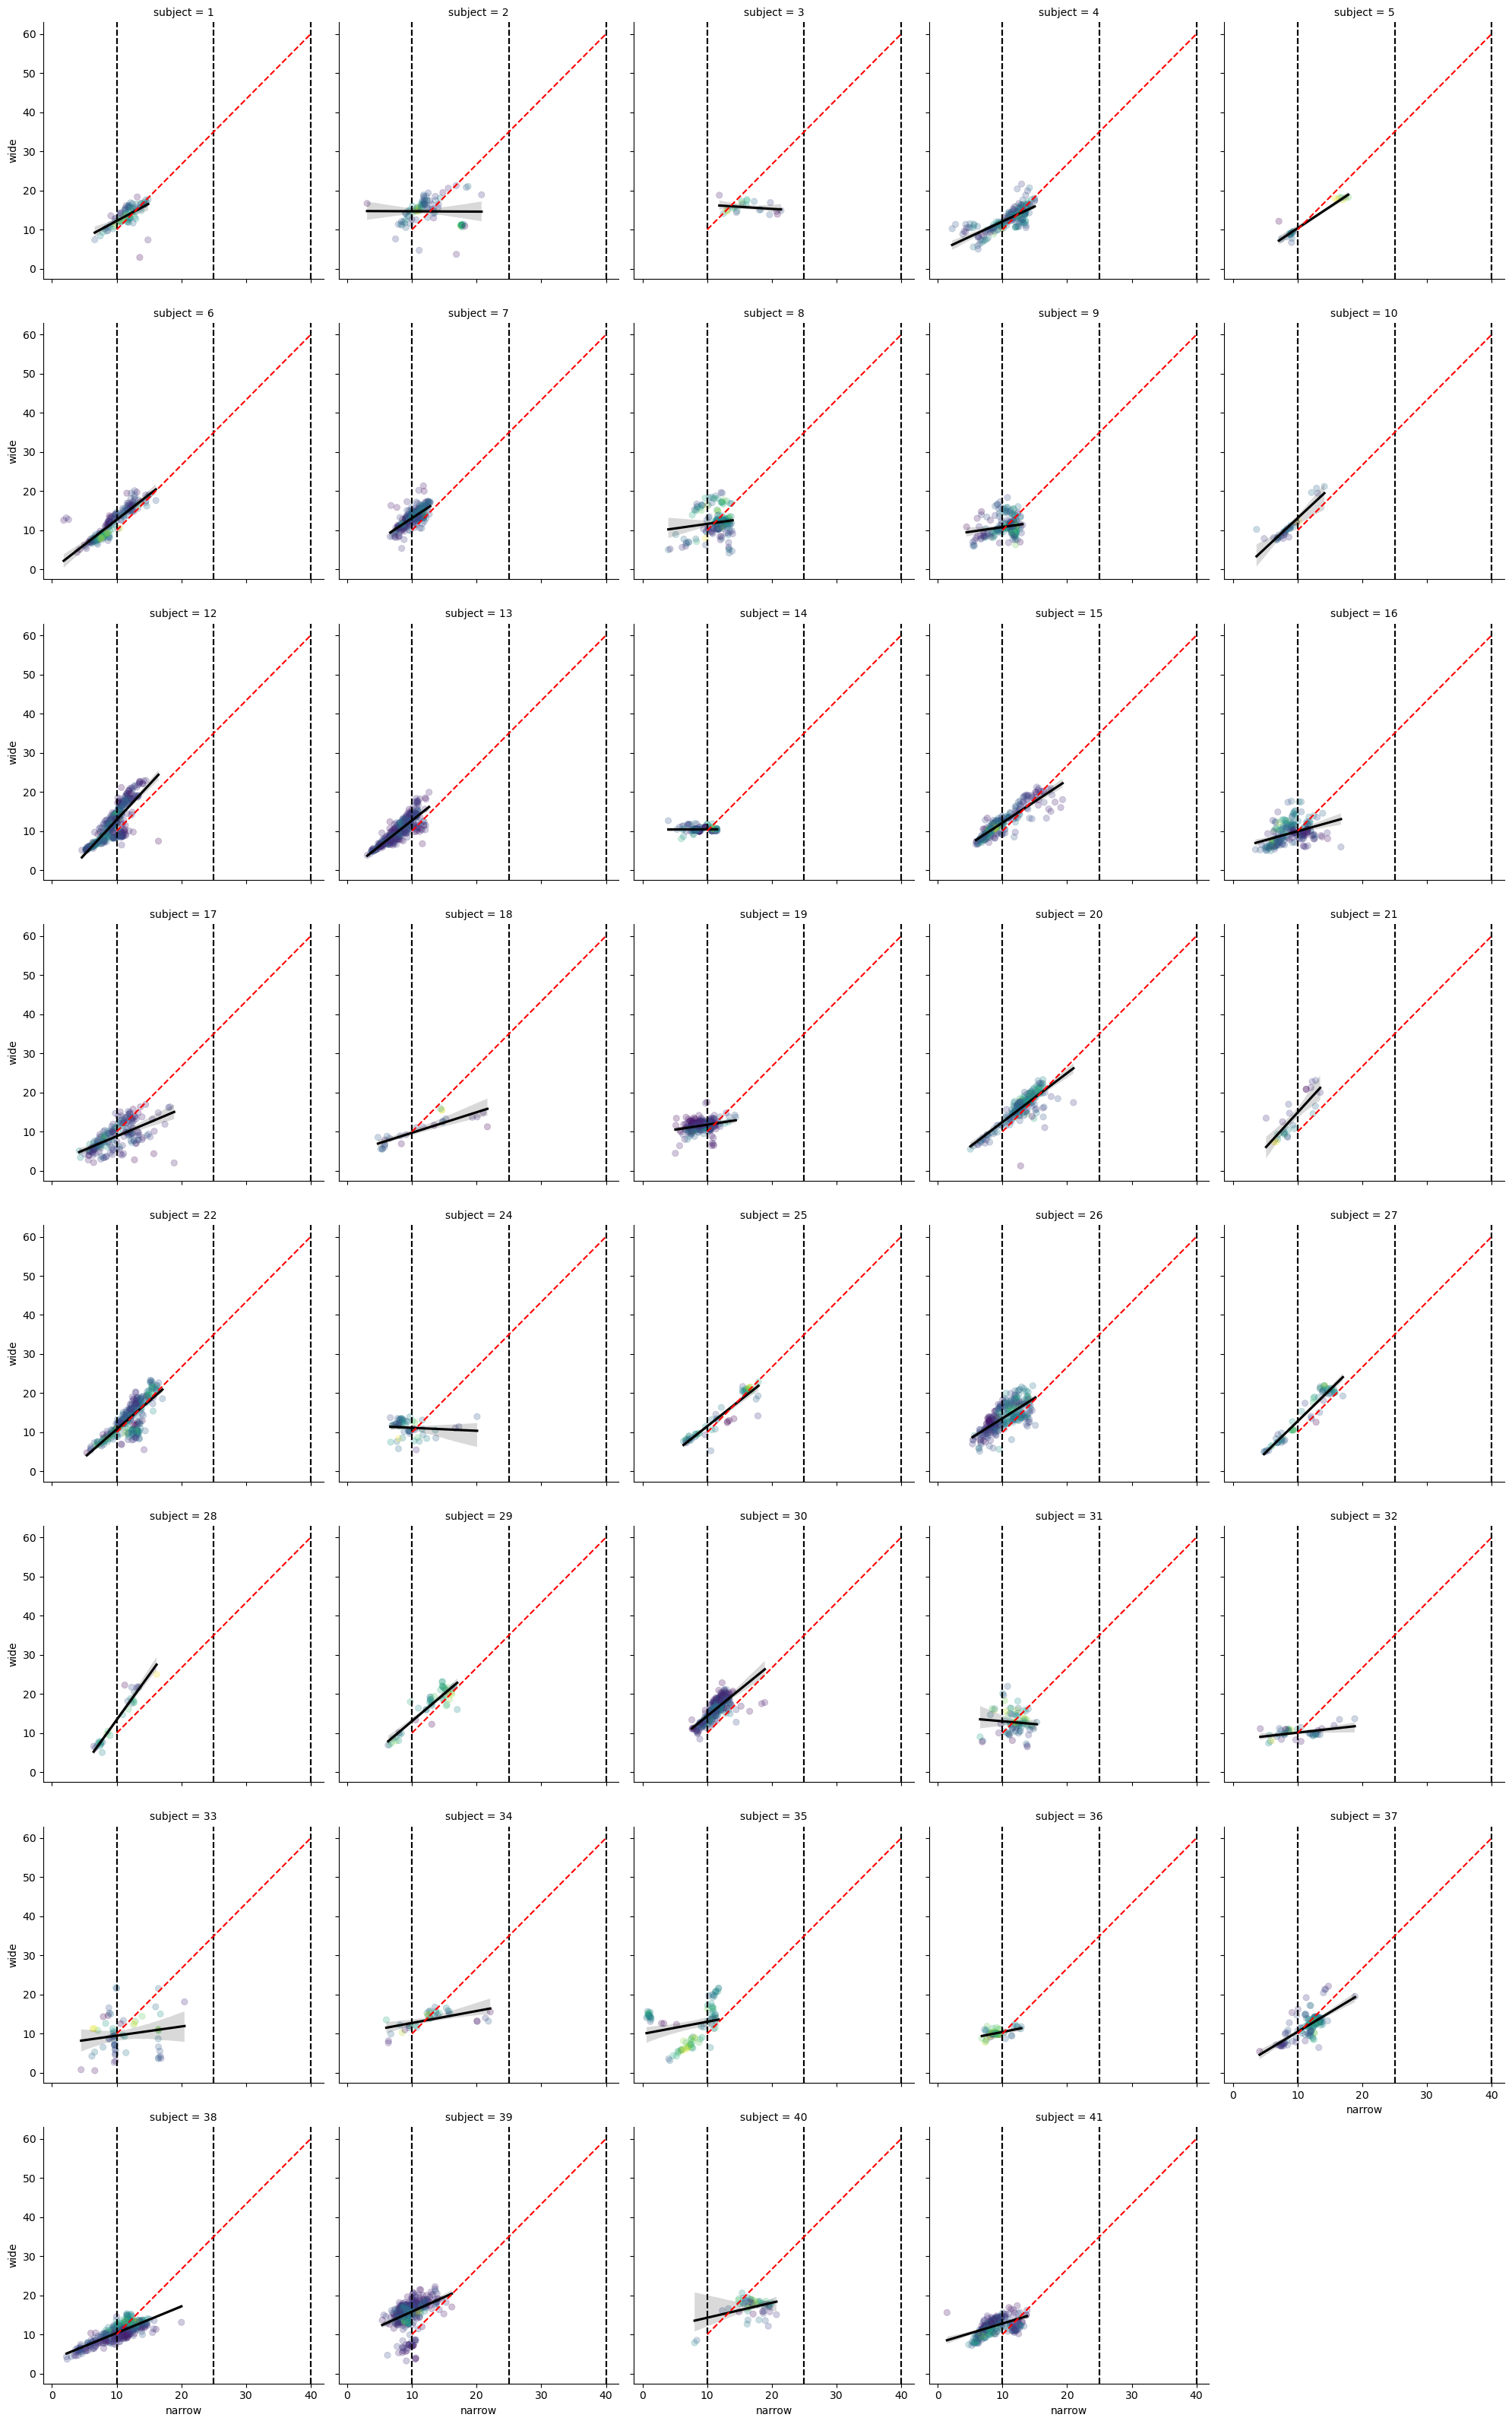

In [103]:
pars6 = pars.loc['alpha'].xs(6, 0, 'model_label')
pars6 = pars6[pars6[('cvr2', 'nan')].gt(0.0)]

mu = pars6[['mu']].droplevel(0, 1)

mu['r2'] = pars6[('r2', 'nan')]
g = sns.FacetGrid(mu.reset_index(), height=4, col='subject', col_wrap=5)

g.map_dataframe(sns.scatterplot, x='narrow', y='wide', edgecolor=None, hue='r2', palette='viridis', alpha=.25)
g.map_dataframe(sns.regplot, x='narrow', y='wide', scatter=False, color='k')

g.map(plt.axvline, x=10, color='k', linestyle='--')
g.map(plt.axvline, x=25, color='k', linestyle='--')
g.map(plt.axvline, x=40, color='k', linestyle='--')


g.map(plt.axvline, x=10, color='k', linestyle='--')
g.map(plt.axvline, x=25, color='k', linestyle='--')
g.map(plt.axvline, x=40, color='k', linestyle='--')
# # Put natural space xticks
# g.set(xlim=(1, 3.7), ylim=(1, 3.7))

# g.map(lambda *args, **kwargs: plt.plot([1, 3.7], [1, 3.7], 'k--'))

slope = 2.
g.map(lambda *args, **kwargs: plt.plot([10, 40], [10, slope*(40-10)], 'r--'))

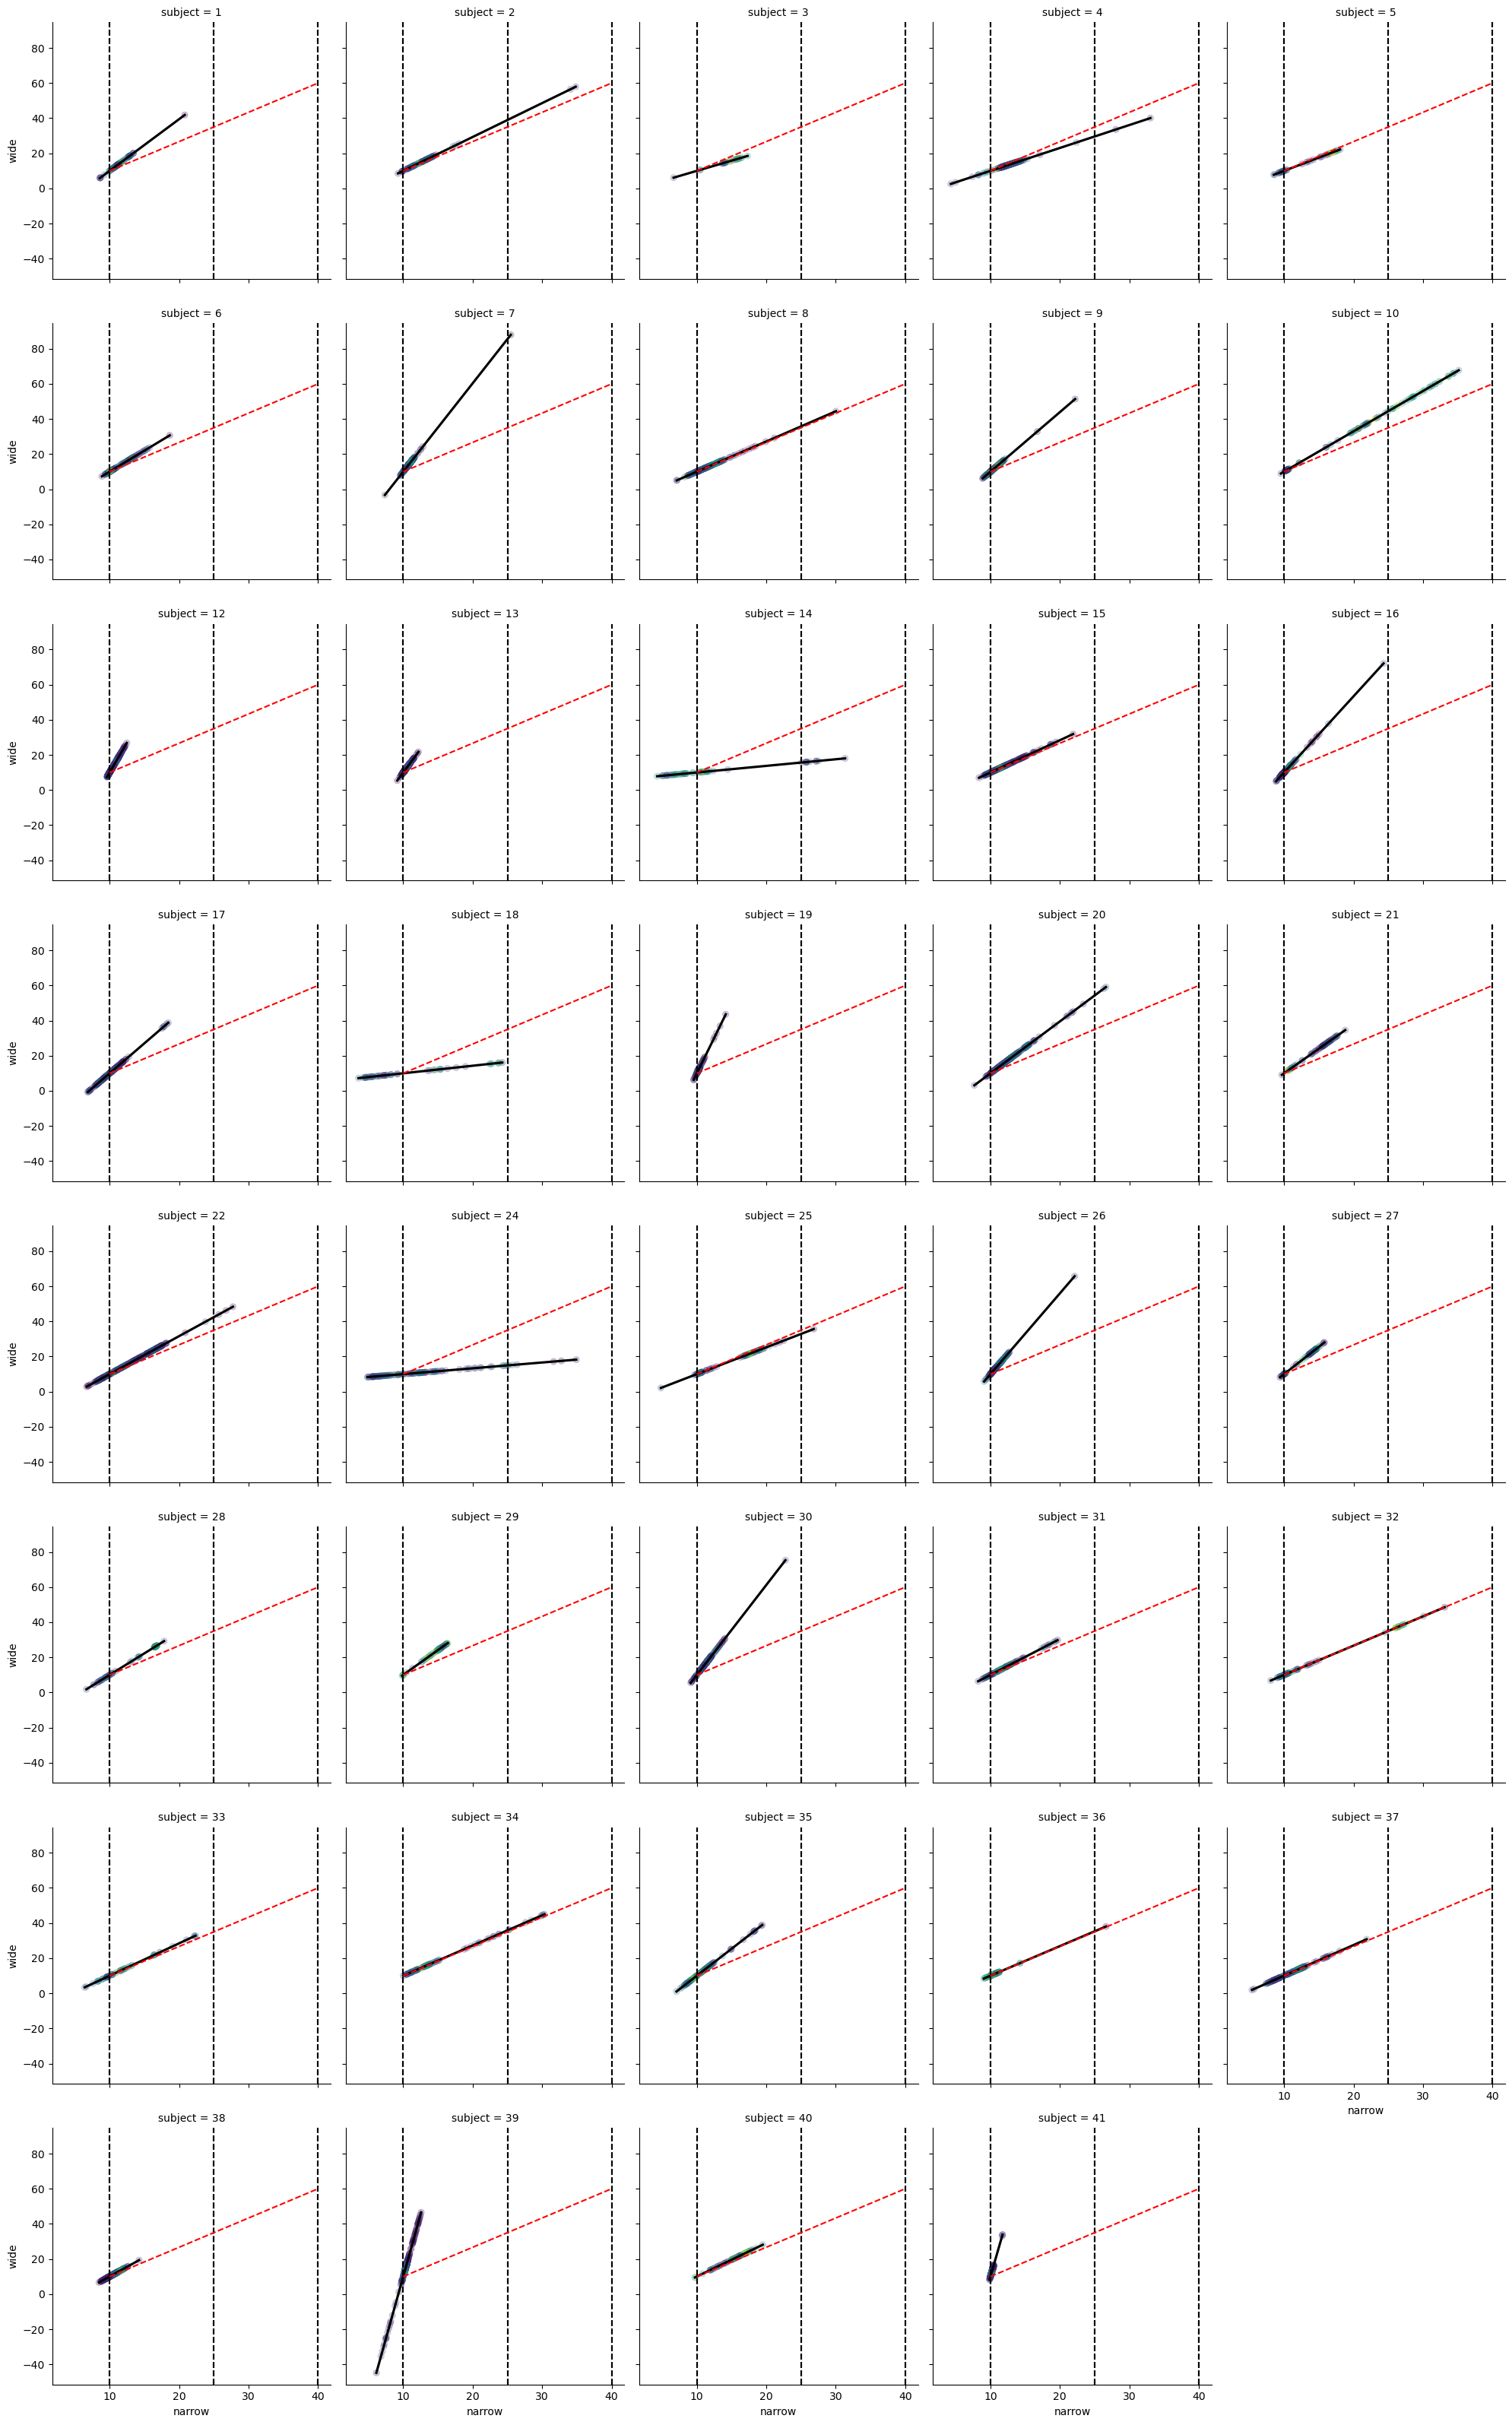

In [60]:
pars6 = pars.loc['alpha'].xs(15, 0, 'model_label')
pars6 = pars6[pars6[('cvr2', 'nan')].gt(0.0)]

mu = pars6[['mu']].droplevel(0, 1)

mu['r2'] = pars6[('r2', 'nan')]
g = sns.FacetGrid(mu.reset_index(), height=4, col='subject', col_wrap=5)

g.map_dataframe(sns.scatterplot, x='narrow', y='wide', edgecolor=None, hue='r2', palette='viridis', alpha=.25)
g.map_dataframe(sns.regplot, x='narrow', y='wide', scatter=False, color='k')

g.map(plt.axvline, x=10, color='k', linestyle='--')
g.map(plt.axvline, x=25, color='k', linestyle='--')
g.map(plt.axvline, x=40, color='k', linestyle='--')


g.map(plt.axvline, x=10, color='k', linestyle='--')
g.map(plt.axvline, x=25, color='k', linestyle='--')
g.map(plt.axvline, x=40, color='k', linestyle='--')
# # Put natural space xticks
# g.set(xlim=(1, 3.7), ylim=(1, 3.7))

# g.map(lambda *args, **kwargs: plt.plot([1, 3.7], [1, 3.7], 'k--'))

slope = 2.
g.map(lambda *args, **kwargs: plt.plot([10, 40], [10, slope*(40-10)], 'r--'))

/var/folders/d4/cpqhwlbn301clph1qk64k01nmjkty3/T/ipykernel_48028/4189831913.py:1: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  tmp = cvr2.stack(['space', 'model_label'])['cvr2']


Text(0.5, 1.0, 'Proportion of voxels with cvR2 > 0.0')

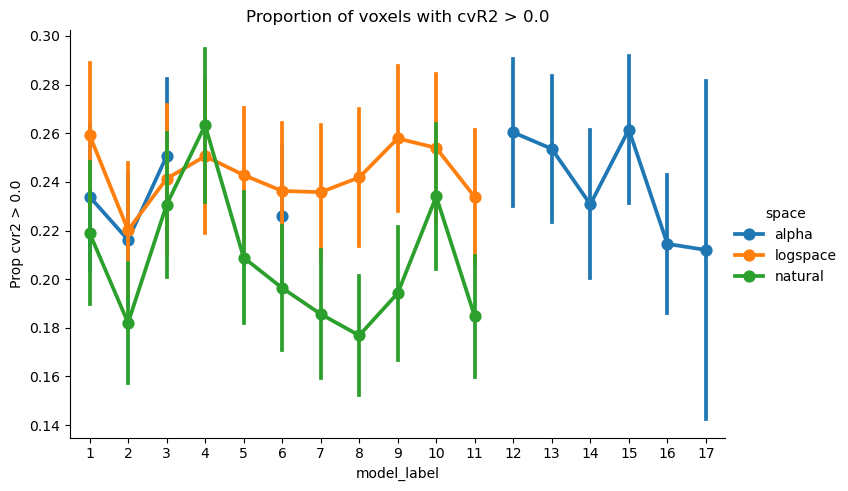

In [110]:
tmp = cvr2.stack(['space', 'model_label'])['cvr2']
tmp = tmp[tmp.notna()]

tmp = (tmp > 0.0).groupby(['subject', 'smoothing', 'space', 'model_label']).mean().to_frame('Prop cvr2 > 0.0')

g = sns.catplot(data=tmp.reset_index(), x='model_label', y='Prop cvr2 > 0.0', hue='space', aspect=1.5, kind='point', col='smoothing', errorbar='se')

plt.title("Proportion of voxels with cvR2 > 0.0")